## Making a jupyter notebook for different plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.ticker import LogLocator
plt.close('all')

dust_dir = ['/home/physics/Research/DUSTY/DUSTY/Lib_nk/', 
            "C:/UTSA/Research/DUSTY/DUSTY/Lib_nk/",
           "C:/Users/uhe082/OneDrive - University of Texas at San Antonio/Lib_nk",
           "C:/Users/uhe082/OneDrive - University of Texas at San Antonio (1)/Yulian Data/"]
# this is the possible locations of where dust can be

fig_dir = ["C:/Users/uhe082/Sean-Dusty/Figures/",
          "/home/physics/Research/DUSTY/DUSTY/Sean_mod/plots/Python_code/Sean-Dusty/Figures/",
          "C:/UTSA/Research/DUSTY/DUSTY/Sean_mod/Python_code/Sean-Dusty/Figures/"]
fd = fig_dir[0]
nk_path = dust_dir[2]               #where the dust is 


### Right Triangle Plot

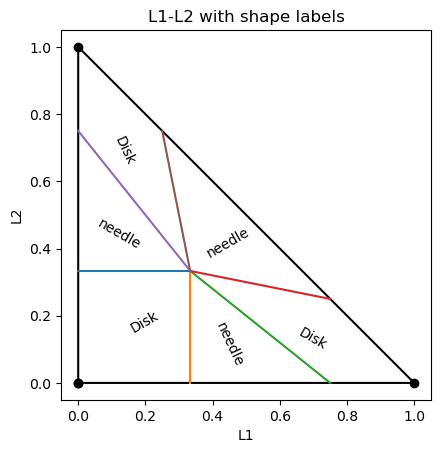

In [2]:
angle_a = np.radians(45)
l1 = (1,0)
l2 = (0,1)
title = 'L1-L2 with shape labels'
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(*zip((0,0), l1, l2, (0,0)), marker='o', color='black')     #makes the triangle 
# ax.plot((0,0.5),l1, label='L1=L3') #blue line
ax.text(0.1, 0.65, 'Disk', rotation=295)
ax.text(0.05, 0.4, 'needle', rotation=330)
ax.text(0.15, 0.15, 'Disk', rotation=30)
ax.text(0.4, 0.05, 'needle', rotation=295)
ax.text(0.65, 0.1, 'Disk', rotation=330)
ax.text(0.375, 0.375, 'needle', rotation=30)
ax.set_xlabel('L1')
ax.set_ylabel('L2')
ax.set_title(title)
# ax.plot(l2, (0.5,0), label='L2=L3')
# ax.plot((0,0.5),(0,0.5), label='L1=L2')
ax.plot((0, 1/3), (1/3,1/3))
ax.plot((1/3,1/3), (0,1/3))
ax.plot((1/3,3/4),(1/3,0))
ax.plot((1/3,3/4),(1/3,1/4))
ax.plot((0,1/3),(3/4,1/3))
ax.plot((1/4,1/3),(3/4,1/3))
# ax.legend()
plt.savefig(fd+"{}.png".format(title))
plt.show()

### SiC - Corman

comparing Silicon Carbide that Pegourie made that corman used in his code.

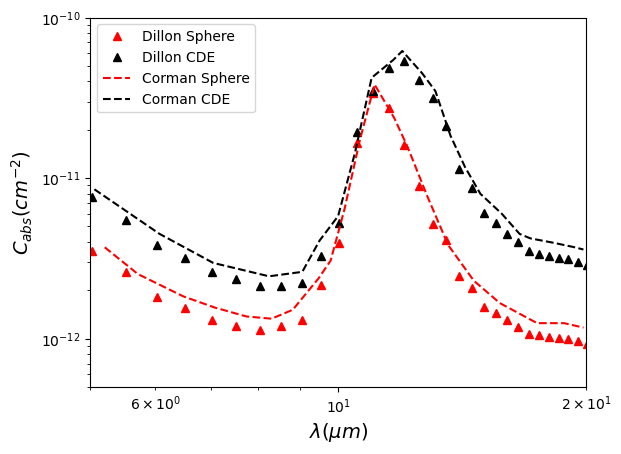

In [50]:
x1, y1, z1 = np.loadtxt('SiC-pegCDE.dat', unpack=True,skiprows=3)  #baseline for comparison
x2, y2, z2 = np.loadtxt('SiC-pegspheres.dat', unpack=True)                           #what we made
x3, y3 = np.loadtxt('pegourie_spher_SiC.csv', unpack=True, delimiter=',', skiprows=1) #what pegourie made
x4, y4 = np.loadtxt('pegourie_cde_SiC.csv', unpack=True, delimiter=',', skiprows=1)
# x5, y5 = np.loadtxt('beta_SiC_spherical_corman_1size_cabs.csv', unpack=True, delimiter=',', skiprows=1) #what corman made
# x6, y6 = np.loadtxt('beta_SiC_CDE_corman_1size_cabs.csv', unpack=True, delimiter=',', skiprows=1)

v_avg = 3.227383793642055e-05

y2 = y2*v_avg/30
#not sure why i have this scaling factor??? but it works???
y1 = y1*v_avg/30

# z2 = z2*v_avg*10

title = 'SiC Pegourie'
fig, ax = plt.subplots()

ax.set(xscale='log', yscale='log')
# ax[1].set(xscale='log', yscale='log')

# ax.set_title(title, fontsize=16)
# ax[1].set_xlabel(r'$\lambda (\mu m)$', fontsize=14)
ax.set_ylabel(r'$C_{abs} (cm^{-2})$', fontsize=14) 
# ax[1].set_ylabel(r'$C_{sca} (\mu m^2)$', fontsize=14)
#Cabs is on ax[0], Csca is on ax[1]
ax.set_xlim(5,20)
ax.set_ylim(5e-13,1e-10)
# ax[1].set_xlim(5,20)

ax.plot(x2, y2, 'r^', label='Dillon Sphere')
ax.plot(x1, y1, 'k^', label='Dillon CDE')
ax.plot(x3, y3, 'r--', label='Corman Sphere')
ax.plot(x4, y4, 'k--', label='Corman CDE')
# ax.plot(x5, y5, label='Corman Sphere')
# ax.plot(x6, y6, label='Corman CDE')
# ax[1].plot(x2, z2, label='Sphere')
# ax[1].plot(x1, z1, label='CDE')
ax.set_xlabel(r'$\lambda (\mu m)$', fontsize=14)


ax.legend(loc='upper left')
plt.savefig(fd+"{}.png".format(title))
plt.show()

### Corundum 
Depew et al 2006

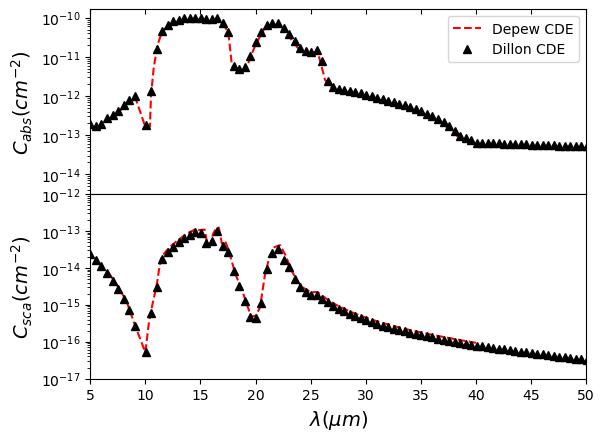

In [6]:

x1, y1, z1 = np.loadtxt('Corundum_cde_depewversion.dat', unpack=True,skiprows=3)  #baseline for comparison
x2, y2, z2 = np.loadtxt('CorundumCDE.dat', unpack=True)                           #what we made

# v_avg = 3.227383793642055e-05 #mrn avg
v_avg = (4./3.)*np.pi*(0.1**3)
rho = 3.33 # density in g um**-3
y2 = y2/(v_avg*rho*5e7)
#not sure why i have this scaling factor??? but it works???

z2 = z2/(v_avg*rho*5e5)

title = 'Corundum baseline'
fig, ax = plt.subplots(2,1, sharex=True)
fig.subplots_adjust(hspace=0.)
ax[0].tick_params(axis='x',direction='in', top=True, bottom=False, labelbottom=False, labeltop=False)

ax[0].set(xscale='linear', yscale='log')
ax[1].set(xscale='linear', yscale='log')

# ax[0].set_title(title, fontsize=16)
ax[1].set_xlabel(r'$\lambda (\mu m)$', fontsize=14)
ax[0].set_ylabel(r'$C_{abs} (cm^{-2})$', fontsize=14) 
ax[1].set_ylabel(r'$C_{sca} (cm^{-2})$', fontsize=14)
#Cabs is on ax[0], Csca is on ax[1]
ax[0].set_xlim(5,50)
ax[1].set_xlim(5,50)
ax[1].set_ylim(1e-17, 1e-12)
ax[0].plot(x1, y1, 'r--', label='Depew CDE')
ax[0].plot(x2, y2, 'k^', label='Dillon CDE')
ax[1].plot(x1, z1, 'r--', label='Depew CDE')
ax[1].plot(x2, z2, 'k^', label='Dillon CDE')


ax[0].legend(loc='best')

# plt.savefig("C:/UTSA/Research/AAS246/{}.png".format(title))
plt.savefig(fd+"{}.png".format(title))
plt.show()

### Fabian 01

Figure 7 comparison
Olivine
Mass Absorption Coefficient


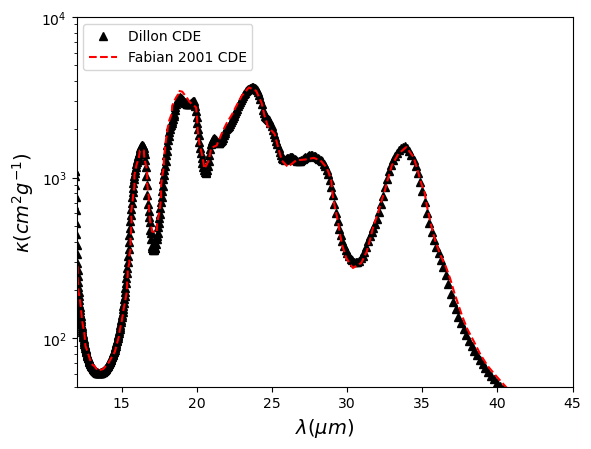

In [44]:
title = 'Olivine Baseline'
x1, y1, z1 = np.loadtxt('oliv_nk_zCDE.dat', unpack=True)
v_avg = 3.227383793642055e-05

x2, y2, z2 = np.loadtxt('oliv_nk_yCDE.dat', unpack=True)

x3, y3, z3 = np.loadtxt('oliv_nk_xCDE.dat', unpack=True)
x4, y4, z4 = np.loadtxt('oli10oli10oli10.dat', unpack=True)
x5, y5 = np.loadtxt('cde1_fab01_fig7_olivine.csv', delimiter=',', skiprows=1, unpack=True)
y4 = np.average((y1,y2[:-1],y3[:-2]),axis=0)
rho = 3.33e-4 # density in g um**-3
k4 = y4/(v_avg * rho) 
fig, ax = plt.subplots()

ax.set(xscale='linear', yscale='log')

# ax.set_title(title, fontsize=16)
ax.set_xlabel(r'$\lambda (\mu m)$', fontsize=14)
ax.set_ylabel(r'$\kappa (cm^2 g^{-1})$', fontsize=14)
ax.set_xlim(12,45)


ax.set_ylim(50,10000)

ax.plot(x4, k4, 'k^',label='Dillon CDE')



ax.plot(x5, y5,'r--', label='Fabian 2001 CDE')
ax.legend(loc='upper left')
plt.savefig(fd+"{}.png".format(title))
plt.show()

### beta-SiC

Corman used the beta SiC and the Pegourie SiC and ran it through his shape code. 

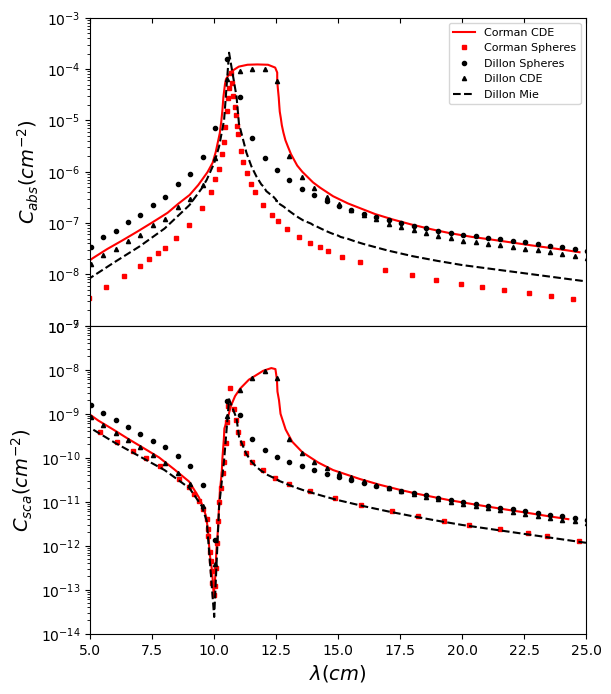

In [45]:
title=r'$\beta$-SiC'
x1, y1 = np.loadtxt('beta_SiC_CDE_corman_1size_cabs.csv', delimiter=',', skiprows=1, unpack=True)       #Ungraphed from Corman
x2, y2 = np.loadtxt('beta_SiC_CDE_corman_1size_csca.csv', delimiter=',', skiprows=1, unpack=True)       #Ungraphed from Corman
x3, y3 = np.loadtxt('beta_SiC_spherical_corman_1size_cabs.csv', delimiter=',', skiprows=1, unpack=True) #Ungraphed from Corman
x4, y4 = np.loadtxt('beta_SiC_spherical_corman_1size_csca.csv', delimiter=',', skiprows=1, unpack=True) #Ungraphed from Corman
x5, y5, z5 = np.loadtxt('beta-SiCspheres.dat', unpack=True)                                             #Our version
x6, y6, z6 = np.loadtxt('beta-SiCCDE.dat', unpack=True)                                                 #Our Version
x7, y7, z7 = np.loadtxt('beta-SiC_mie.dat', unpack=True)
x5*=1e4
y3*=1e-4
y1*=3e-4
y2*=2e-6
y5*=3e-6
z5*=2e-20
y4*=2e-6

fig, ax = plt.subplots(2,1, sharex=True, figsize=[6.4,8])
fig.subplots_adjust(hspace=0.)
ax[0].set(xscale='linear', yscale='log')
ax[1].set(xscale='linear', yscale='log')


ax[0].tick_params(axis='x',direction='in', top=True, bottom=False, labelbottom=False, labeltop=False)
# ax[1].get_yticks(minor=True)
# ax[1].tick_params(axis='y', which='minor', direction='out', left=True)
ax[1].yaxis.set_minor_locator(LogLocator(base=10, subs='all'))

# ax[0].set_title(title, fontsize=16)
ax[1].set_xlabel(r'$\lambda (cm)$', fontsize=14)
ax[0].set_ylabel(r'$C_{abs} (cm^{-2})$', fontsize=14) 
ax[1].set_ylabel(r'$C_{sca} (cm^{-2})$', fontsize=14)
#Cabs is on ax[0], Csca is on ax[1]
ax[0].set_xlim(5,25)
ax[1].set_xlim(5,25)
ax[0].set_ylim(1e-9, 1e-3)
ax[1].set_ylim(1e-14, 1e-7)
#Cabs plots
ax[0].plot(x1, y1, 'r-', label='Corman CDE', markersize=3)
ax[0].plot(x3, y3, 'rs', label='Corman Spheres', markersize=3)
ax[0].plot(x5, y5, 'ko', label='Dillon Spheres', markersize=3)
ax[0].plot(x6, y6, 'k^', label='Dillon CDE', markersize=3)
ax[0].plot(x7, y7, 'k--', label='Dillon Mie', markersize=3)
#Csca plots
ax[1].plot(x2, y2, 'r-', label='Corman CDE', markersize=3)
ax[1].plot(x4, y4, 'rs', label='Corman Spheres', markersize=3)
ax[1].plot(x5, z5, 'ko', label='Dillon Spheres', markersize=3)
ax[1].plot(x6, z6, 'k^', label='Dillon CDE', markersize=3)
ax[1].plot(x7, z7, 'k--', label='Dillon Mie', markersize=3)

ax[0].legend(loc='upper right', fontsize=8)
plt.savefig(fd+"beta-SiC.png")


### ISM Std

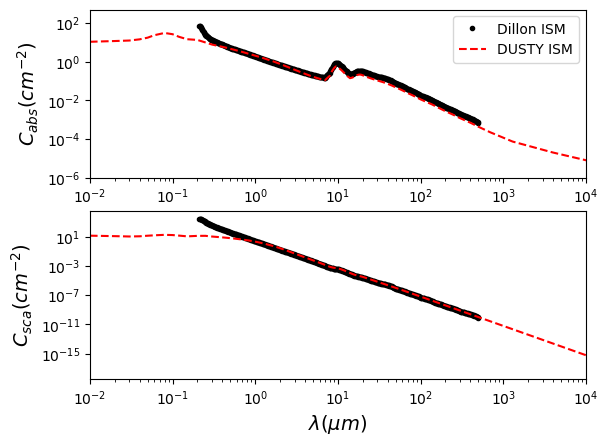

In [138]:
title='Interstellar Medium'

x1, y1, z1 = np.loadtxt('ISM_std_spheres.dat', unpack=True, skiprows=3)
x2, y2, z2 = np.loadtxt('ism-stnd.dat', unpack=True, skiprows=3)

y1*=5e4
z1*=8e6
fig, ax = plt.subplots(2,1)

ax[0].set(xscale='log', yscale='log')
ax[1].set(xscale='log', yscale='log')
ax[0].set_xlim(1e-2,1e4)
ax[1].set_xlim(1e-2,1e4)
ax[0].set_ylim(1e-6, 5e2)
# ax[1].set_ylim(1e-8, 1e1)

ax[0].set_title(title, fontsize=16)
ax[1].set_xlabel(r'$\lambda (cm)$', fontsize=14)
ax[0].set_ylabel(r'$C_{abs} (cm^{-2})$', fontsize=14) 
ax[1].set_ylabel(r'$C_{sca} (cm^{-2})$', fontsize=14)
#Cabs plots
ax[0].plot(x1, y1, 'ko', label='Dillon ISM', markersize=3)
ax[0].plot(x2, y2, 'r--', label='DUSTY ISM', markersize=3)

#Csca plots
ax[1].plot(x1, z1, 'ko', label='Dillon ISM', markersize=3)
ax[1].plot(x2, z2, 'r--', label='DUSTY ISM', markersize=3)

ax[1].set_xlabel(r'$\lambda (\mu m)$', fontsize=14)
ax[0].set_ylabel(r'$C_{abs} (cm^{-2})$', fontsize=14) 
ax[1].set_ylabel(r'$C_{sca} (cm^{-2})$', fontsize=14)

ax[0].legend(loc='upper right', fontsize=10)
plt.savefig(fd+"{}.png".format(title))


### DUSTY Comparison

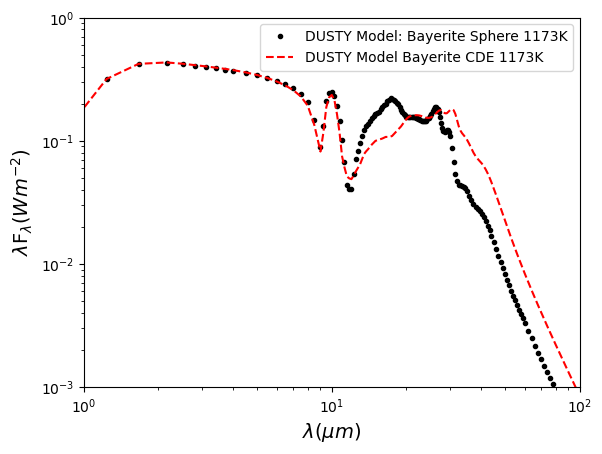

In [4]:
title="DUSTY Bayerite comparison"
fig,ax = plt.subplots()

x1, y1 = np.loadtxt('baysphere-6.s002',  usecols=(0,1), unpack=True,)
x2, y2 = np.loadtxt('bayCDE-6.s002',  usecols=(0,1), unpack=True,)
# x3, y3 = np.loadtxt(path3+'.s002',  usecols=(0,1), unpack=True,)

ax.set(xscale='log', yscale='log')

# ax.set_title(m, fontsize=16)
ax.set_xlabel(r'$\lambda (\mu m)$', fontsize=14)
ax.set_ylabel(r'$\lambda$F$_{\lambda} (W m^{-2})$', fontsize=14)
ax.set_xlim(1,1e2)
ax.set_ylim(1e-3, 1e0)

ax.plot(x1, y1, 'ko', label='DUSTY Model: Bayerite Sphere 1173K', markersize=3)
ax.plot(x2, y2, 'r--', label='DUSTY Model Bayerite CDE 1173K', markersize=3)

ax.legend()
plt.savefig(fd+"{}.png".format(title))

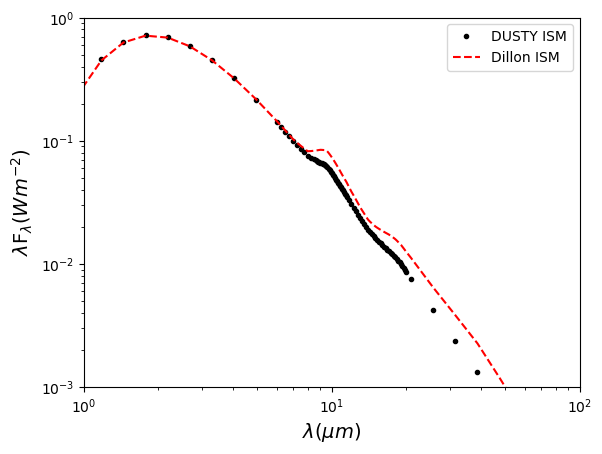

In [9]:
title="DUSTY Bayerite comparison"
modA = "042" #original ISM
modB = "041" #Dillon ISM
x1, y1 = np.loadtxt(nk_path+"Model{}/sphere1.s002".format(modA),  usecols=(0,1), unpack=True,skiprows=8)
x2, y2 = np.loadtxt(nk_path+"Model{}/sphere1.s002".format(modB),  usecols=(0,1), unpack=True,skiprows=8)

fig,ax = plt.subplots()
ax.set_xlabel(r'$\lambda (\mu m)$', fontsize=14)
ax.set_ylabel(r'$\lambda$F$_{\lambda} (W m^{-2})$', fontsize=14)
ax.set(xscale='log', yscale='log')
ax.set_xlim(1,1e2)
ax.set_ylim(1e-3, 1e0)

ax.plot(x1, y1, 'ko', label='DUSTY ISM', markersize=3)
ax.plot(x2, y2, 'r--', label='Dillon ISM', markersize=3)

ax.legend()



### Size and Shape Comparisons

NameError: name 'x1' is not defined

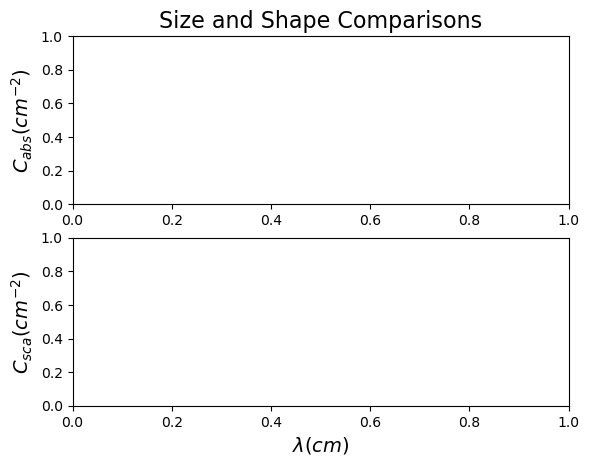

In [2]:
title="Size and Shape Comparisons"
fig,ax = plt.subplots(2,1)

ax[0].set_title(title, fontsize=16)
ax[1].set_xlabel(r'$\lambda (cm)$', fontsize=14)
ax[0].set_ylabel(r'$C_{abs} (cm^{-2})$', fontsize=14) 
ax[1].set_ylabel(r'$C_{sca} (cm^{-2})$', fontsize=14)
#Cabs plots
ax[0].plot(x1, y1, 'ko', label='CDE Dust single grain size', markersize=3)
ax[0].plot(x2, y2, 'r-', label='CDE Dust MRN-average', markersize=3)
ax[0].plot(x3, y3, '..', label='CDE Dust KMH-average', markersize=3)
ax[0].plot(x4, y4, 'ko', label='Mie Sphere Dust single grain size', markersize=3)
ax[0].plot(x5, y5, 'r-', label='Mie Sphere Dust MRN-average', markersize=3)
ax[0].plot(x6, y6, '..', label='Mie Sphere Dust KMH-average', markersize=3)
ax[0].plot(x7, y7, 'ko', label='Sphere Calc Dust single grain size', markersize=3)
ax[0].plot(x8, y8, 'r-', label='Sphere Calc Dust  MRN-average', markersize=3)
ax[0].plot(x9, y9, '..', label='Sphere Calc Dust  KMH-average', markersize=3)

#Csca plots
ax[1].plot(x1, z1, 'ko', label='Dillon ISM', markersize=3)
ax[1].plot(x2, z2, 'r--', label='DUSTY ISM', markersize=3)
